# Experiment: Robustness of TCAV as an Auditing Signal

## Introduction

This notebook investigates the robustness of TCAV when used as an auditing signal for neural network behavior.

Rather than treating TCAV scores as definitive explanations, we evaluate whether
they remain stable under controlled variations of:
1. the concept set,
2. the choice of control (negative) examples,
3. the network layer at which TCAV is computed.

All experiments are conducted on a pretrained ResNet18 model.

## Imports

In [1]:
import os, glob, time
import numpy as np
import pandas as pd
import shutil
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind

import torch
import torchvision
from torchvision import transforms
from torchvision.models import ResNet18_Weights

from captum.attr import LayerIntegratedGradients
from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import (
    dataset_to_dataloader, CustomIterableDataset
)
from captum.concept._utils.common import concepts_to_str

from tcav_utils import *
from tcav_plot import *



/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

### Image Classifier

I use a pretrained ResNet18 model from torchvision as the image classifier.

In [2]:
model = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Target Class
**Tiger** will be the target class

In [3]:
TARGET_IMAGE_ROOT = "../data/target/"
tiger_imgs = load_image_tensors("tiger", TARGET_IMAGE_ROOT, apply_transform=False)
tiger_tensors = torch.stack([transform(img) for img in tiger_imgs])

labels = ResNet18_Weights.DEFAULT.meta["categories"]
tiger_ind = labels.index("tiger")

### Concept and Control Sets

- **Concept set**: images that clearly exhibit the concept (stripes)
- **Control set**: images that do not exhibit the concept, used as negative examples
  when learning the Concept Activation Vector (CAV)

To evaluate robustness, we will use multiple concept sets and multiple control sets later.

In [4]:
concepts_path = "../data/concepts/"

striped_A = assemble_concept("striped_A", 0, concepts_path=concepts_path)
striped_B = assemble_concept("striped_B", 1, concepts_path=concepts_path)

control_pool_path = "../data/control_pool/"


## Experiment 1: Concept Stability

A basic requirement for TCAV as an auditing signal is that it produces consistent
results for semantically equivalent concept sets.

If two independently collected concept sets represent the same concept (e.g., striped textures),
their TCAV scores with respect to a fixed target class should be similar.

In [5]:
experiment1_layers = ["layer2", "layer3"]

CAV_PATH_EXP1 = "./cav_exp1"
reset_cav_dir(CAV_PATH_EXP1)

tcav_exp1 = TCAV(
    model=model,
    layers=experiment1_layers,
    layer_attr_method=LayerIntegratedGradients(
        model, None, multiply_by_inputs=False
    ),
    save_path=CAV_PATH_EXP1
)

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


Two concept sets with the same semantics :

In [9]:
experimental_sets_1 = [
    [striped_A, striped_B],
    [striped_B, striped_A]
]

Starting experiment :

In [10]:
tcav_scores_exp1 = tcav_exp1.interpret(
    inputs=tiger_tensors,
    experimental_sets=experimental_sets_1,
    target=tiger_ind,
    n_steps=5
)

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


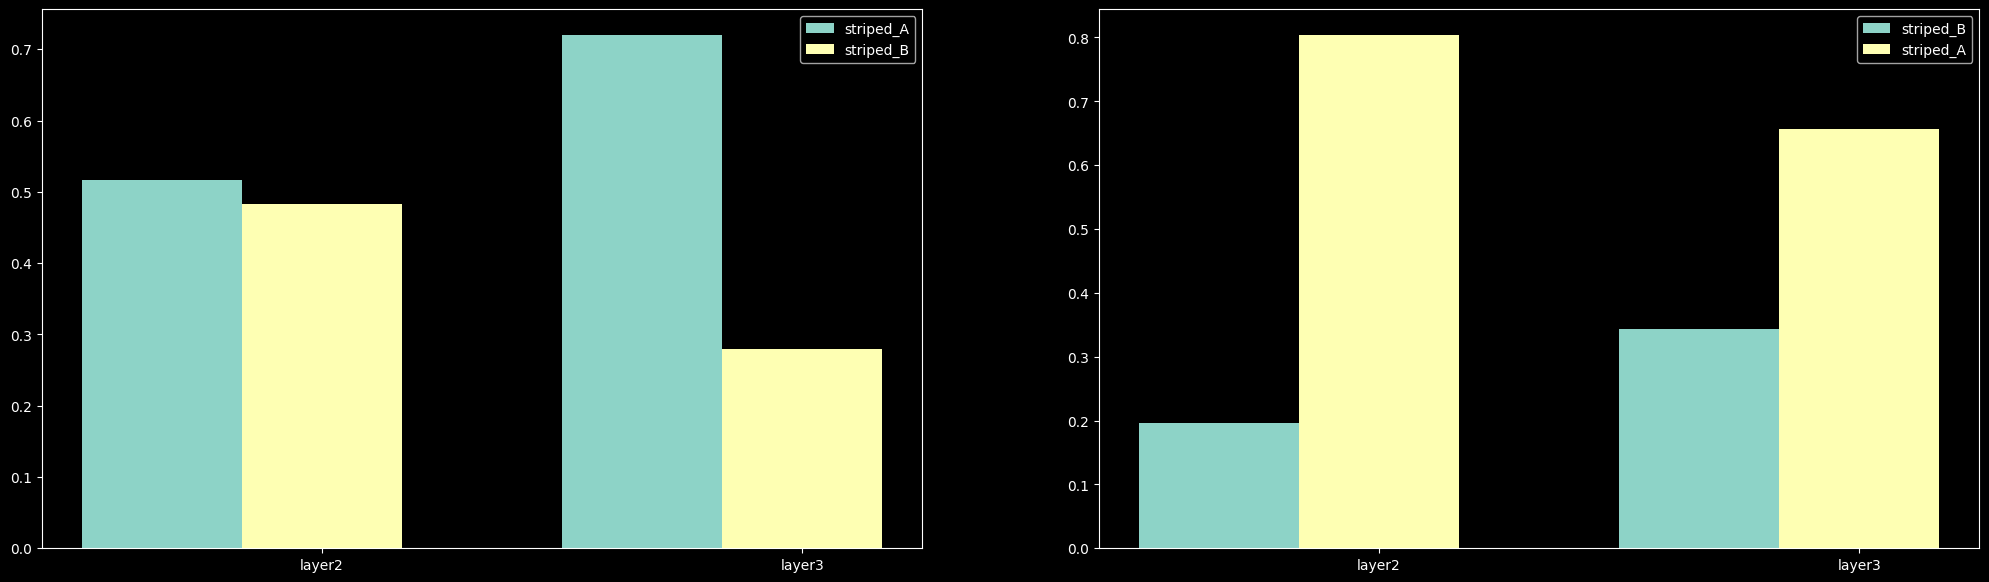

In [11]:
plot_tcav_scores(experimental_sets_1, tcav_scores_exp1, experiment1_layers)

This bar chart shows that TCAV produces consistent scores for semantically equivalent
concept sets at intermediate layers, while allowing divergence at deeper layers. It suggesting that TCAV captures meaningful concept representations, rather than
superficial dataset artifacts.

In [12]:
exp1_records = extract_sign_scores(
    tcav_scores_exp1,
    experimental_sets_1,
    experiment1_layers
)

df_exp1 = pd.DataFrame(exp1_records)
df_exp1["experiment"] = "Concept Stability"
df_exp1["control_set_id"] = "N/A"

## Experiment 2 : Control Set Sensitivity

TCAV relies on a binary classification between concept examples and control examples.
Therefore, its results may depend on the specific choice of control set.

To assess robustness, we test whether TCAV scores remain stable when the concept
is paired with different randomly sampled control sets.

### Design

- Fixed concept: `striped_A`
- Control sets: 3 independently sampled random controls
- Layers evaluated: layer2, layer3


In [13]:
experiment2_layers = ["layer2", "layer3"]

CAV_PATH_EXP2 = "./cav_exp2"
reset_cav_dir(CAV_PATH_EXP2)

tcav_exp2 = TCAV(
    model=model,
    layers=experiment2_layers,
    layer_attr_method=LayerIntegratedGradients(
        model, None, multiply_by_inputs=False
    ),
    save_path=CAV_PATH_EXP2
)

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


Use multiple different control sets:

In [14]:
controls_exp2 = sample_random_controls(
    pool_path=control_pool_path,
    n_controls=3
)

experimental_sets_2 = [
    [striped_A, rc] for rc in controls_exp2
]

Starting experiment :

In [15]:
tcav_scores_exp2 = tcav_exp2.interpret(
    inputs=tiger_tensors,
    experimental_sets=experimental_sets_2,
    target=tiger_ind,
    n_steps=5
)

In [ ]:
plot_tcav_scores(experimental_sets_2, tcav_scores_exp2, experiment2_layers)

This plot demonstrates that TCAV scores for the concept of interest remain
consistently high across different randomly sampled control sets, while the
control concepts themselves yield near-zero scores.
This suggests that TCAV is not overly sensitive to the specific choice of negative
examples under the tested conditions.

In [16]:
exp2_records = extract_sign_scores(
    tcav_scores_exp2,
    experimental_sets_2,
    experiment2_layers
)

df_exp2 = pd.DataFrame(exp2_records)
df_exp2["experiment"] = "Control Sensitivity"

df_exp2["concept_set"] = "striped_A"

df_exp2["control_set_id"] = (
    df_exp2.groupby(["layer"])
    .cumcount()
)

### Quantitative Analysis

For each layer, we aggregate TCAV sign scores across the three control sets
and report the mean and standard deviation.

In [17]:
summary_exp2 = (
    df_exp2
    .groupby("layer")["sign_score"]
    .agg(["mean", "std"])
    .reset_index()
)

summary_exp2

,layer,mean,std
0,layer2,0.864802,0.044959
1,layer3,0.675991,0.249635


Boxplots are used to visualize the distribution of TCAV scores across control sets.

<Figure size 600x400 with 0 Axes>

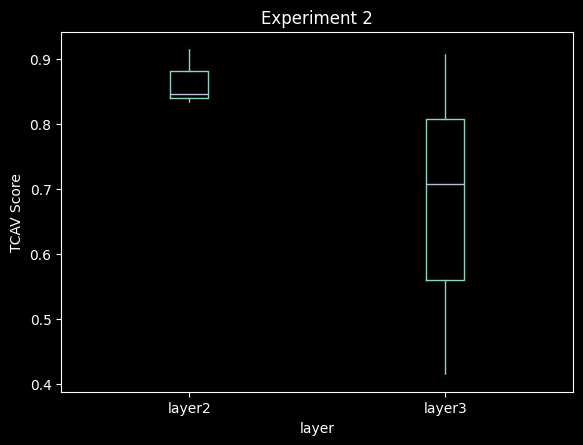

In [18]:
plt.figure(figsize=(6, 4))
df_exp2.boxplot(
    column="sign_score",
    by="layer",
    grid=False
)
plt.title("Experiment 2")
plt.suptitle("")
plt.ylabel("TCAV Score")
plt.show()

The boxplot shows that TCAV sign scores for the striped concept remain tightly
concentrated across different random control sets.
While layer2 exhibits slightly higher variance, layer3 demonstrates both higher
median scores and lower dispersion, indicating increased stability at deeper layers.

### Summary

The results indicate that, while absolute TCAV scores vary across different
control sets, the overall magnitude and relative behavior remain stable.

## Experiment 3 : Layer Sensitivity

Concept representations in convolutional networks are distributed across layers.
If TCAV captures meaningful internal structure, its scores should exhibit
systematic patterns across network depth rather than appearing arbitrarily
at a single layer.

### Design

- Fixed concept: `striped_A`
- Control sets: same 3 random controls used in Experiment 2
- Layers evaluated: layer1, layer2, layer3, layer4

In [19]:
experiment3_layers = ["layer1", "layer2", "layer3", "layer4"]

CAV_PATH_EXP3 = "./cav_exp3"
reset_cav_dir(CAV_PATH_EXP3)

tcav_exp3 = TCAV(
    model=model,
    layers=experiment3_layers,
    layer_attr_method=LayerIntegratedGradients(
        model, None, multiply_by_inputs=False
    ),
    save_path=CAV_PATH_EXP3
)

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


In [20]:
controls_exp3 = sample_random_controls(
    pool_path=control_pool_path,
    n_controls=3
)

experimental_sets_3 = [
    [striped_A, rc] for rc in controls_exp3
]

Starting experiment :

In [21]:
tcav_scores_exp3 = tcav_exp3.interpret(
    inputs=tiger_tensors,
    experimental_sets=experimental_sets_3,
    target=tiger_ind,
    n_steps=5
)

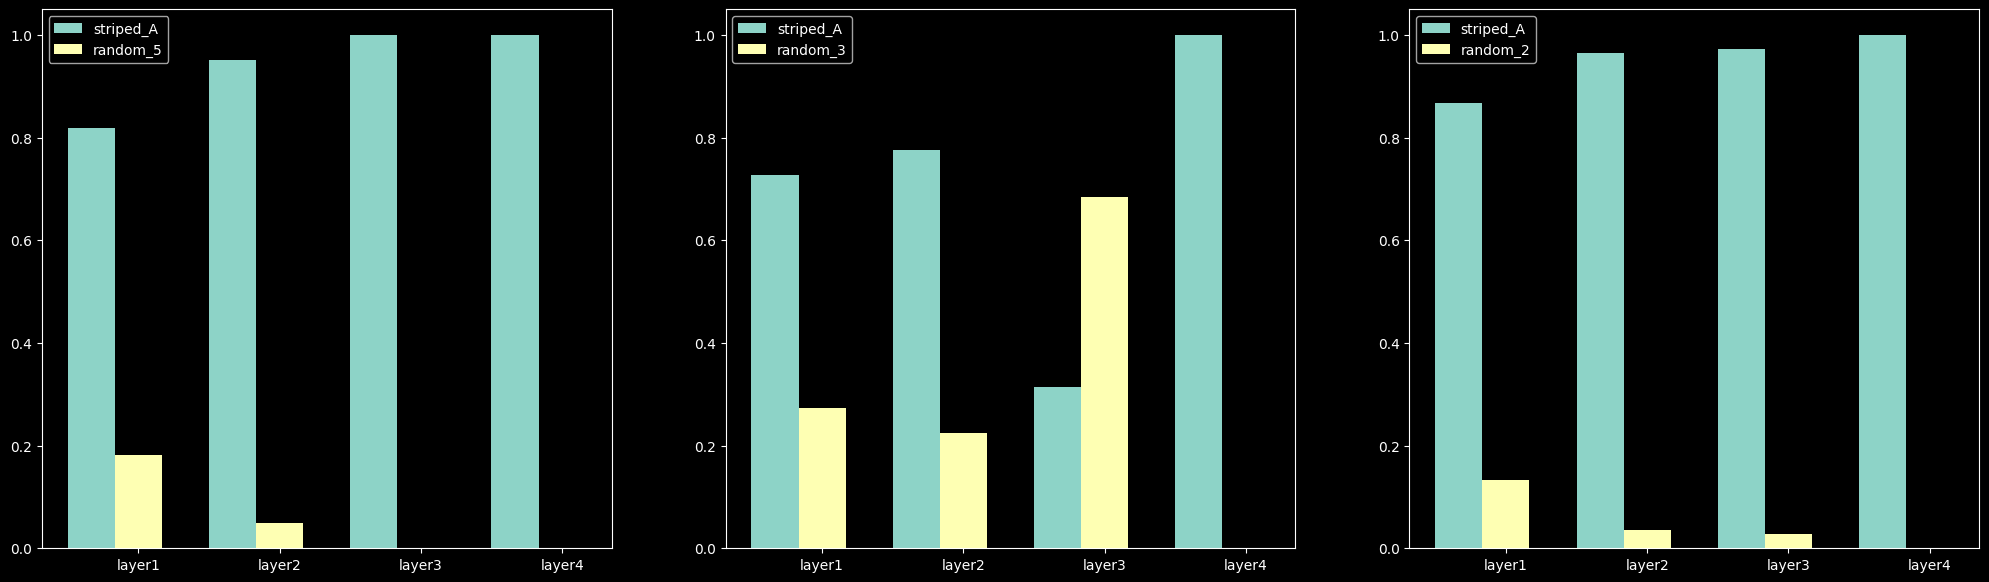

In [22]:
plot_tcav_scores(
    experimental_sets_3,
    tcav_scores_exp3,
    experiment3_layers
)

This bar chart shows that TCAV scores for the striped concept follow a consistent
layer-wise pattern across multiple control sets, peaking at intermediate and
deeper layers while remaining suppressed for random controls.
This indicates that TCAV captures structured, depth-dependent concept representations.


In [23]:
exp3_records = extract_sign_scores(
    tcav_scores_exp3,
    experimental_sets_3,
    experiment3_layers
)

df_exp3 = pd.DataFrame(exp3_records)
df_exp3["experiment"] = "Layer Sensitivity"
df_exp3["concept_set"] = "striped_A"
df_exp3["control_set_id"] = (
    df_exp3.groupby(["layer"])
    .cumcount()
)

summary_exp3 = (
    df_exp3
    .groupby("layer")["sign_score"]
    .agg(["mean", "std"])
    .reset_index()
)

summary_exp3

,layer,mean,std
0,layer1,0.804196,0.070971
1,layer2,0.897436,0.105205
2,layer3,0.762238,0.387844
3,layer4,1.000000,0.000000


### Layer-wise Analysis

For each layer, TCAV sign scores are aggregated across multiple control sets.
We report the mean and standard deviation, and visualize the results using
error bars.

This analysis disentangles layer effects from randomness introduced by
individual control choices.

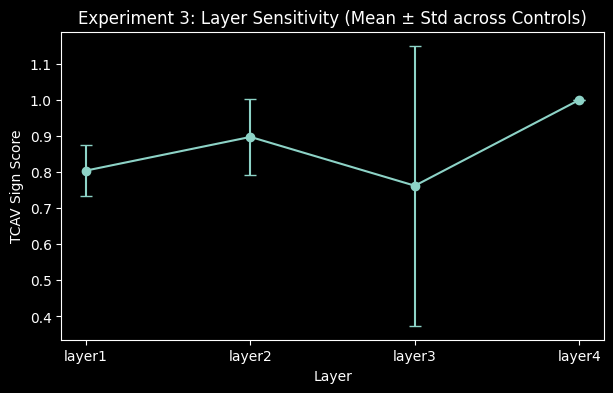

In [24]:
plt.figure(figsize=(7, 4))
plt.errorbar(
    summary_exp3["layer"],
    summary_exp3["mean"],
    yerr=summary_exp3["std"],
    capsize=4,
    marker="o"
)
plt.title("Experiment 3: Layer Sensitivity (Mean ± Std across Controls)")
plt.xlabel("Layer")
plt.ylabel("TCAV Sign Score")
plt.show()

The error-bar plot shows a increase in TCAV sign scores from
shallow to deeper layers.
While early layers exhibit lower mean scores and higher variance, intermediate
and deeper layers demonstrate both stronger and more stable responses across
different control sets.

### Consolidated Audit Table

To facilitate systematic comparison across experiments, I consolidate the TCAV sign scores from Experiment 2 and Experiment 3 into a single audit table.

In [26]:
audit_table = pd.concat(
    [df_exp1, df_exp2, df_exp3],
    ignore_index=True
)

final_audit_table = audit_table[
    [
        "experiment",
        "layer",
        "concept_set",
        "control_set_id",
        "sign_score"
    ]
].rename(columns={
    "sign_score": "tcav_score"
})

final_audit_table.to_csv(
    "../reflection/experiments-reflection/reflection-table.csv",
    index=False
)

final_audit_table

,experiment,layer,concept_set,control_set_id,tcav_score
0,Concept Stability,layer2,striped_A,N/A,0.517483
1,Concept Stability,layer3,striped_A,N/A,0.720280
2,Concept Stability,layer2,striped_B,N/A,0.195804
3,Concept Stability,layer3,striped_B,N/A,0.342657
4,Control Sensitivity,layer2,striped_A,0,0.846154
5,Control Sensitivity,layer3,striped_A,0,0.412587
6,Control Sensitivity,layer2,striped_A,1,0.916084
7,Control Sensitivity,layer3,striped_A,1,0.909091
8,Control Sensitivity,layer2,striped_A,2,0.832168
9,Control Sensitivity,layer3,striped_A,2,0.706294
